In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score


In [2]:
df = pd.read_csv('sales_data.csv.txt')

df.head()

,Month,Sales
0,1,1200
1,2,1400
2,3,1600
3,4,1800
4,5,2000


In [3]:
print(df.isnull().sum())


Month    0
Sales    0
dtype: int64


In [4]:
df = df.dropna()

In [5]:
X = df[['Month']]
y = df['Sales']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[200.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Month']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1000
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [8]:
y_pred = model.predict(X_test)

print(y_pred)

[3200. 3000. 1200.]


In [9]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 1.5158245029548803e-13
R2 Score: 1.0


In [10]:
future_months = pd.DataFrame({
    'Month':[13,14,15,16,17,18]
})

future_sales = model.predict(future_months)

print(future_sales)

[3600. 3800. 4000. 4200. 4400. 4600.]


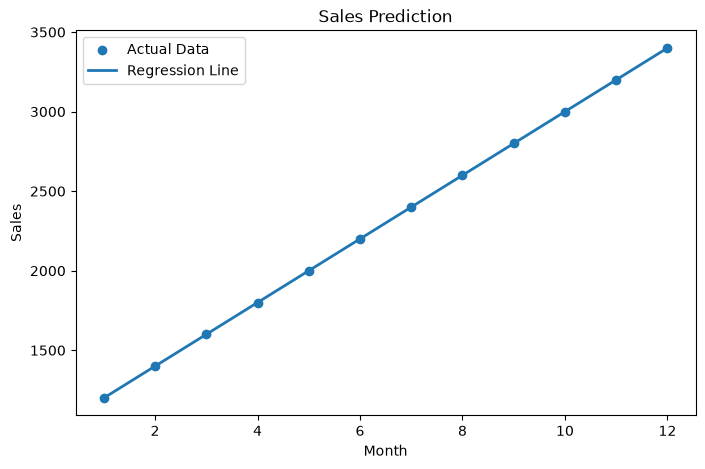

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, label='Actual Data')

plt.plot(
    X,
    model.predict(X),
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Sales Prediction')
plt.legend()

plt.show()

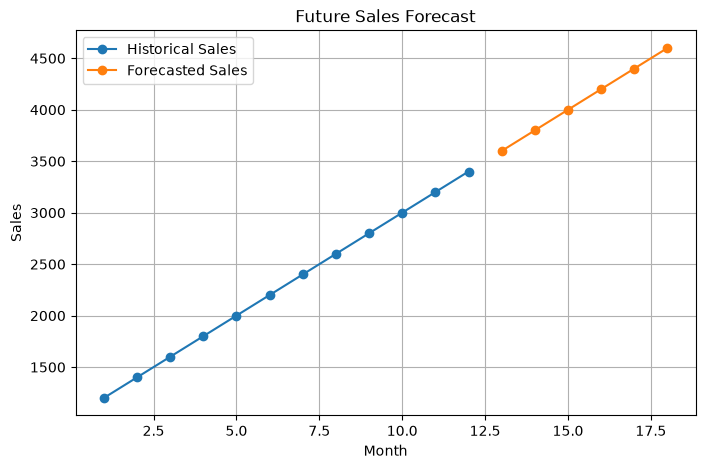

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    df['Month'],
    df['Sales'],
    marker='o',
    label='Historical Sales'
)

plt.plot(
    future_months['Month'],
    future_sales,
    marker='o',
    label='Forecasted Sales'
)

plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Future Sales Forecast')

plt.legend()
plt.grid(True)

plt.show()